# 一、数据读取与预处理

In [1]:
data_dir = './flower_data/'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'

In [38]:
from torchvision import transforms,datasets,models  # 导入数据变换模块 数据集处理模块 模型结构
import torch
import os
import json
from torch import nn
from torch import optim

"""
- data_transforms中指定了所有图像预处理操作
- ImageFolder假设所有的文件按文件夹保存好，每个文件夹下面存贮同一类别的图片，文件夹的名字为分类的名字
"""

data_transforms = {
    'train':
        transforms.Compose([
        transforms.Resize([96, 96]),  # 指定缩放大小
        transforms.RandomRotation(45),#随机旋转，-45到45度之间随机选
        transforms.CenterCrop(64),#从中心开始裁剪到指定尺寸 一般与transforms.Resize配合使用
        transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转 选择一个概率概率
        transforms.RandomVerticalFlip(p=0.5),#随机垂直翻转
        transforms.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1, hue=0.1),#参数1为亮度，参数2为对比度，参数3为饱和度，参数4为色相 用的不多，除非是极端光照条件下或者极端天气情况
        transforms.RandomGrayscale(p=0.025),#概率转换成灰度率，3通道就是R=G=B  不常用
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  #均值，标准差 经验值
    ]),
    'valid':
        transforms.Compose([
        transforms.Resize([64, 64]),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [5]:
batch_size = 128

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'valid']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True) for x in ['train', 'valid']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

In [11]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 6552
     Root location: ./flower_data/train
     StandardTransform
 Transform: Compose(
                Resize(size=[96, 96], interpolation=bilinear, max_size=None, antialias=True)
                RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
                CenterCrop(size=(64, 64))
                RandomHorizontalFlip(p=0.5)
                RandomVerticalFlip(p=0.5)
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=(-0.1, 0.1))
                RandomGrayscale(p=0.025)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 818
     Root location: ./flower_data/valid
     StandardTransform
 Transform: Compose(
                Resize(size=[64, 64], interpolation=bilinear, max_size=None, antialias=True)
                ToTe

In [12]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x15ea2ac8650>,
 'valid': <torch.utils.data.dataloader.DataLoader at 0x15ee02c54d0>}

In [13]:
dataset_sizes

{'train': 6552, 'valid': 818}

In [14]:
class_names

['1',
 '10',
 '100',
 '101',
 '102',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '4',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '5',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '6',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '7',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '8',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '9',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99']

In [16]:
with open('cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f) # 将内容转为字典对象

cat_to_name

{'21': 'fire lily',
 '3': 'canterbury bells',
 '45': 'bolero deep blue',
 '1': 'pink primrose',
 '34': 'mexican aster',
 '27': 'prince of wales feathers',
 '7': 'moon orchid',
 '16': 'globe-flower',
 '25': 'grape hyacinth',
 '26': 'corn poppy',
 '79': 'toad lily',
 '39': 'siam tulip',
 '24': 'red ginger',
 '67': 'spring crocus',
 '35': 'alpine sea holly',
 '32': 'garden phlox',
 '10': 'globe thistle',
 '6': 'tiger lily',
 '93': 'ball moss',
 '33': 'love in the mist',
 '9': 'monkshood',
 '102': 'blackberry lily',
 '14': 'spear thistle',
 '19': 'balloon flower',
 '100': 'blanket flower',
 '13': 'king protea',
 '49': 'oxeye daisy',
 '15': 'yellow iris',
 '61': 'cautleya spicata',
 '31': 'carnation',
 '64': 'silverbush',
 '68': 'bearded iris',
 '63': 'black-eyed susan',
 '69': 'windflower',
 '62': 'japanese anemone',
 '20': 'giant white arum lily',
 '38': 'great masterwort',
 '4': 'sweet pea',
 '86': 'tree mallow',
 '101': 'trumpet creeper',
 '42': 'daffodil',
 '22': 'pincushion flower',
 

# 二、网络模块设置

In [17]:
# 加载models中提供的模型，并且直接用训练的好权重当做初始化参数
# 第一次执行需要下载，可能会比较慢
model_name = 'resnet'  #可选的比较多 ['resnet', 'alexnet', 'vgg', 'squeezenet', 'densenet', 'inception']
#是否用人家训练好的特征来做
feature_extract = True #都用人家特征，咱先不更新

In [18]:
# 是否用GPU训练
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CUDA is available!  Training on GPU ...


In [21]:
model_ft = models.resnet18()#18层的能快点，条件好点的也可以选152
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
for name,param in model_ft.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.we

In [27]:
def set_parameter_requires_grad(model, feature_extracting):
    """ 是否更新权重 """
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [31]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    """ 初始化模型 """
    model_ft = models.resnet18(pretrained=use_pretrained) # 下载预训练模型 默认存放user/.cache/torch
    set_parameter_requires_grad(model_ft, feature_extract)  # 是否更新权重

    num_ftrs = model_ft.fc.in_features  # 获取名称为fc层的输入通道数
    model_ft.fc = nn.Linear(num_ftrs, num_classes)   # 重新创建fc层覆盖原来的  类别数自己根据自己任务来

    return model_ft

In [45]:
"""设置哪些层需要训练  """
model_ft = initialize_model(model_name, 102, feature_extract, use_pretrained=True)

#GPU还是CPU计算
model_ft = model_ft.to(device)

#模型保存，名字自己起
filename='best.pt'

# 是否训练所有层
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

Params to learn:
	 fc.weight
	 fc.bias


In [37]:
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:

# 优化器设置
optimizer_ft = optim.Adam(params_to_update, lr=1e-2)#要训练啥参数，你来定
#设置衰减策略 学习率每10个epoch衰减成原来的1/10 解决 “固定学习率训练时后期收敛慢、易震荡” 的问题。
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.1)
criterion = nn.CrossEntropyLoss()

In [42]:
optimizer_ft.param_groups[0]

{'params': [Parameter containing:
  tensor([[ 0.0395,  0.0071, -0.0396,  ...,  0.0221,  0.0248,  0.0383],
          [ 0.0239, -0.0033, -0.0124,  ..., -0.0347,  0.0236,  0.0320],
          [ 0.0338, -0.0224,  0.0273,  ..., -0.0094, -0.0348,  0.0219],
          ...,
          [-0.0103,  0.0240, -0.0157,  ..., -0.0104,  0.0245,  0.0382],
          [ 0.0206, -0.0270, -0.0311,  ..., -0.0380,  0.0198, -0.0361],
          [-0.0185,  0.0240,  0.0025,  ...,  0.0020, -0.0062,  0.0127]],
         device='cuda:0', requires_grad=True),
  Parameter containing:
  tensor([ 0.0409,  0.0113,  0.0038,  0.0234,  0.0137,  0.0349, -0.0261,  0.0284,
          -0.0049, -0.0144,  0.0324,  0.0171,  0.0174,  0.0405,  0.0051,  0.0022,
          -0.0032, -0.0076, -0.0101, -0.0159,  0.0344, -0.0138, -0.0340,  0.0327,
           0.0095, -0.0375, -0.0307, -0.0431, -0.0041, -0.0348,  0.0204, -0.0245,
           0.0032, -0.0125, -0.0086,  0.0262, -0.0347, -0.0384, -0.0379,  0.0344,
           0.0182,  0.0225, -0.0441, 

In [43]:
import time
import copy

def train_model(model, dataloaders, criterion, optimizer, num_epochs=25,filename='best.pt'):
    """

    :param model:  模型
    :param dataloaders: 数据集
    :param criterion: 损失函数
    :param optimizer:  优化器
    :param num_epochs: 训练轮数
    :param filename:  模型保存的名字
    :return:  model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs
    """
    #咱们要算时间的
    since = time.time()
    #也要记录最好的那一次
    best_acc = 0
    #模型也得放到你的CPU或者GPU
    model.to(device)
    #训练过程中打印一堆损失和指标
    val_acc_history = []
    train_acc_history = []
    train_losses = []
    valid_losses = []
    #学习率
    LRs = [optimizer.param_groups[0]['lr']]  # 从优化器中获取最初的学习率
    #最好的那次模型，后续会变的，先初始化
    best_model_wts = copy.deepcopy(model.state_dict())
    #一个个epoch来遍历
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # 训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # 训练
            else:
                model.eval()   # 验证

            running_loss = 0.0
            running_corrects = 0

            # 把数据都取个遍
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)#放到你的CPU或GPU
                labels = labels.to(device)

                # 清零
                optimizer.zero_grad()
                # 只有训练的时候计算和更新梯度
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                # 训练阶段更新权重
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # 计算损失
                 # inputs.size(0) 表示一个batch的图片数量 loss.item() 表示批次平均损失  将 “批次平均损失” 还原为 “当前批次的总损失”：
                running_loss += loss.item() * inputs.size(0)
                # 计算出当前批次预测正确额数量
                running_corrects += torch.sum(preds == labels.data)#预测结果最大的和真实值是否一致



            epoch_loss = running_loss / len(dataloaders[phase].dataset)#算平均
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            time_elapsed = time.time() - since#一个epoch我浪费了多少时间
            print('Time elapsed {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))


            # 得到最好那次的模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                state = {
                  'state_dict': model.state_dict(),#字典里key就是各层的名字，值就是训练好的权重
                  'best_acc': best_acc,
                  'optimizer' : optimizer.state_dict(),
                }
                torch.save(state, filename)
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                #scheduler.step(epoch_loss)#学习率衰减
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)

        print('Optimizer learning rate : {:.7f}'.format(optimizer.param_groups[0]['lr']))
        LRs.append(optimizer.param_groups[0]['lr'])
        print()
        scheduler.step()#学习率衰减

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # 训练完后用最好的一次当做模型最终的结果,等着一会测试
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs

In [44]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs  = train_model(model_ft, dataloaders, criterion, optimizer_ft, num_epochs=20)

Epoch 0/19
----------
Time elapsed 0m 23s
train Loss: 3.9546 Acc: 0.2515
Time elapsed 0m 25s
valid Loss: 3.3581 Acc: 0.3007
Optimizer learning rate : 0.0100000

Epoch 1/19
----------
Time elapsed 0m 47s
train Loss: 2.7870 Acc: 0.4022
Time elapsed 0m 49s
valid Loss: 3.5533 Acc: 0.2946
Optimizer learning rate : 0.0100000

Epoch 2/19
----------
Time elapsed 1m 9s
train Loss: 2.7229 Acc: 0.4196
Time elapsed 1m 11s
valid Loss: 3.6232 Acc: 0.3337
Optimizer learning rate : 0.0100000

Epoch 3/19
----------
Time elapsed 1m 31s
train Loss: 2.7521 Acc: 0.4332
Time elapsed 1m 33s
valid Loss: 4.1724 Acc: 0.2751
Optimizer learning rate : 0.0100000

Epoch 4/19
----------
Time elapsed 1m 51s
train Loss: 2.8551 Acc: 0.4298
Time elapsed 1m 53s
valid Loss: 3.9618 Acc: 0.2983
Optimizer learning rate : 0.0100000

Epoch 5/19
----------
Time elapsed 2m 11s
train Loss: 2.7511 Acc: 0.4484
Time elapsed 2m 12s
valid Loss: 4.0280 Acc: 0.3081
Optimizer learning rate : 0.0100000

Epoch 6/19
----------
Time elapsed 

In [54]:
# 加载之前训练好的权重参数

checkpoint = torch.load(filename)
best_acc = checkpoint['best_acc']
model_ft.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [55]:

for param in model_ft.parameters():
    param.requires_grad = True

# 再继续训练所有的参数，学习率调小一点
optimizer = optim.Adam(model_ft.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 损失函数
criterion = nn.CrossEntropyLoss()

In [56]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs  = train_model(model_ft, dataloaders, criterion, optimizer, num_epochs=10,)

Epoch 0/9
----------
Time elapsed 0m 18s
train Loss: 0.7007 Acc: 0.7981
Time elapsed 0m 20s
valid Loss: 1.8657 Acc: 0.5868
Optimizer learning rate : 0.0010000

Epoch 1/9
----------
Time elapsed 0m 38s
train Loss: 0.5891 Acc: 0.8298
Time elapsed 0m 39s
valid Loss: 1.9935 Acc: 0.5648
Optimizer learning rate : 0.0010000

Epoch 2/9
----------
Time elapsed 0m 57s
train Loss: 0.4870 Acc: 0.8640
Time elapsed 0m 59s
valid Loss: 1.6055 Acc: 0.6479
Optimizer learning rate : 0.0010000

Epoch 3/9
----------
Time elapsed 1m 16s
train Loss: 0.5579 Acc: 0.8434
Time elapsed 1m 18s
valid Loss: 2.5726 Acc: 0.5330
Optimizer learning rate : 0.0010000

Epoch 4/9
----------
Time elapsed 1m 38s
train Loss: 0.5811 Acc: 0.8385
Time elapsed 1m 40s
valid Loss: 1.5947 Acc: 0.6369
Optimizer learning rate : 0.0010000

Epoch 5/9
----------
Time elapsed 1m 59s
train Loss: 0.5882 Acc: 0.8349
Time elapsed 2m 1s
valid Loss: 2.0123 Acc: 0.5831
Optimizer learning rate : 0.0010000

Epoch 6/9
----------
Time elapsed 2m 20s


# 三、模型测试
- 测试数据处理方法需要跟训练时一样才可以
- crop操作的目的是保证输入的大小是一致的
- 标准化操作也是必须的，用跟训练数据相同的mean和std,但是需要注意一点训练数据是在0-1上进行标准化，所以测试数据也需要先归一化
- 最后一点，PyTorch中颜色通道是第一个维度，跟很多工具包都不一样，需要转换


In [70]:
# 得到一个batch的测试数据
dataiter = iter(dataloaders['valid'])
print(dataiter)
images, labels = dataiter.__next__()
print(labels)
model_ft.eval()

if train_on_gpu:
    output = model_ft(images.cuda())
else:
    output = model_ft(images)

tensor([ 85,  38,  63,  73,  18, 100,  83,   2,  38,  33,  99,  49,  56,  64,
         76,  99,  39,  97,  82,  89,  17,  59,   6,  97,  59,  73,  81,  33,
         51,  15,  88,  19,   7,   0,  73,  78,  60,  34,   6,   7,  79,  12,
         85,  96,  13,  51,  36, 101,  76,  50,  77,  21,  64,  40,   1,  53,
         47,  46,  89,  81,  26,  76,  48,  60,   9,  47,   2,  74,  49,  34,
         55,  41,  43,  90,  52,  72,  51,  19,  25,  49,  53,  62,  11,  70,
         97,  97,  14,  43,  59,  87,  42,  40,  93,  64,  65,  90,  97,  65,
          7,  70,  14,  71,  78,  12,  56,  30,  90,  70,  49,  49,   1,  82,
         45, 101,  56,  18,  81,  79,  55,  40,  46,  90,  95,  38,  82,  81,
         38,  29])


In [71]:
output.shape

torch.Size([128, 102])

In [72]:
import numpy as np

_, preds_tensor = torch.max(output, 1)

preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())
preds

array([ 73,  38,  63,  73,  24,  53,  77,   2,  38,  33,  99,  49,  56,
        64,  76,  37,  80,  97,  61,  89,  17,  59,   6,  97,  59,  73,
        89,  33,  78,  15,  88,  19,   7,   0,  73,  78,  60,  34,   6,
         7,  79,  54,  73,  96,  53,  55,  53,  80,  76,  55,  77,  21,
        64, 100,   1,  53,  47,  46,  89,  81,  56,  76,  48,  60,   9,
         6,   2,  74,  49,  34,  55,  41,  49,  90,  52,  32,  51,  19,
        91,  49,  53,  80,  11,  70,  81,   9,  14,  89,  59,  28,  42,
        84,   7,  64,  65,  90,  97,  28,  77,  70,  14,  71,  78,  85,
        56,  30,   3,  70,  49,  40,   1,  82,  45, 101,  49,  55,  81,
        79,  55,  77,  29,  54,  55,  47,  82,  81,  83,  29])

In [73]:
def im_convert(tensor):
    """ 展示数据"""
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)  # 小于 0 的值被强制设为 0，大于 1 的值被强制设为 1

    return image


preds前5个值： [73, 38, 63, 73, 24, 53, 77, 2]
labels前5个值： [85, 38, 63, 73, 18, 100, 83, 2]


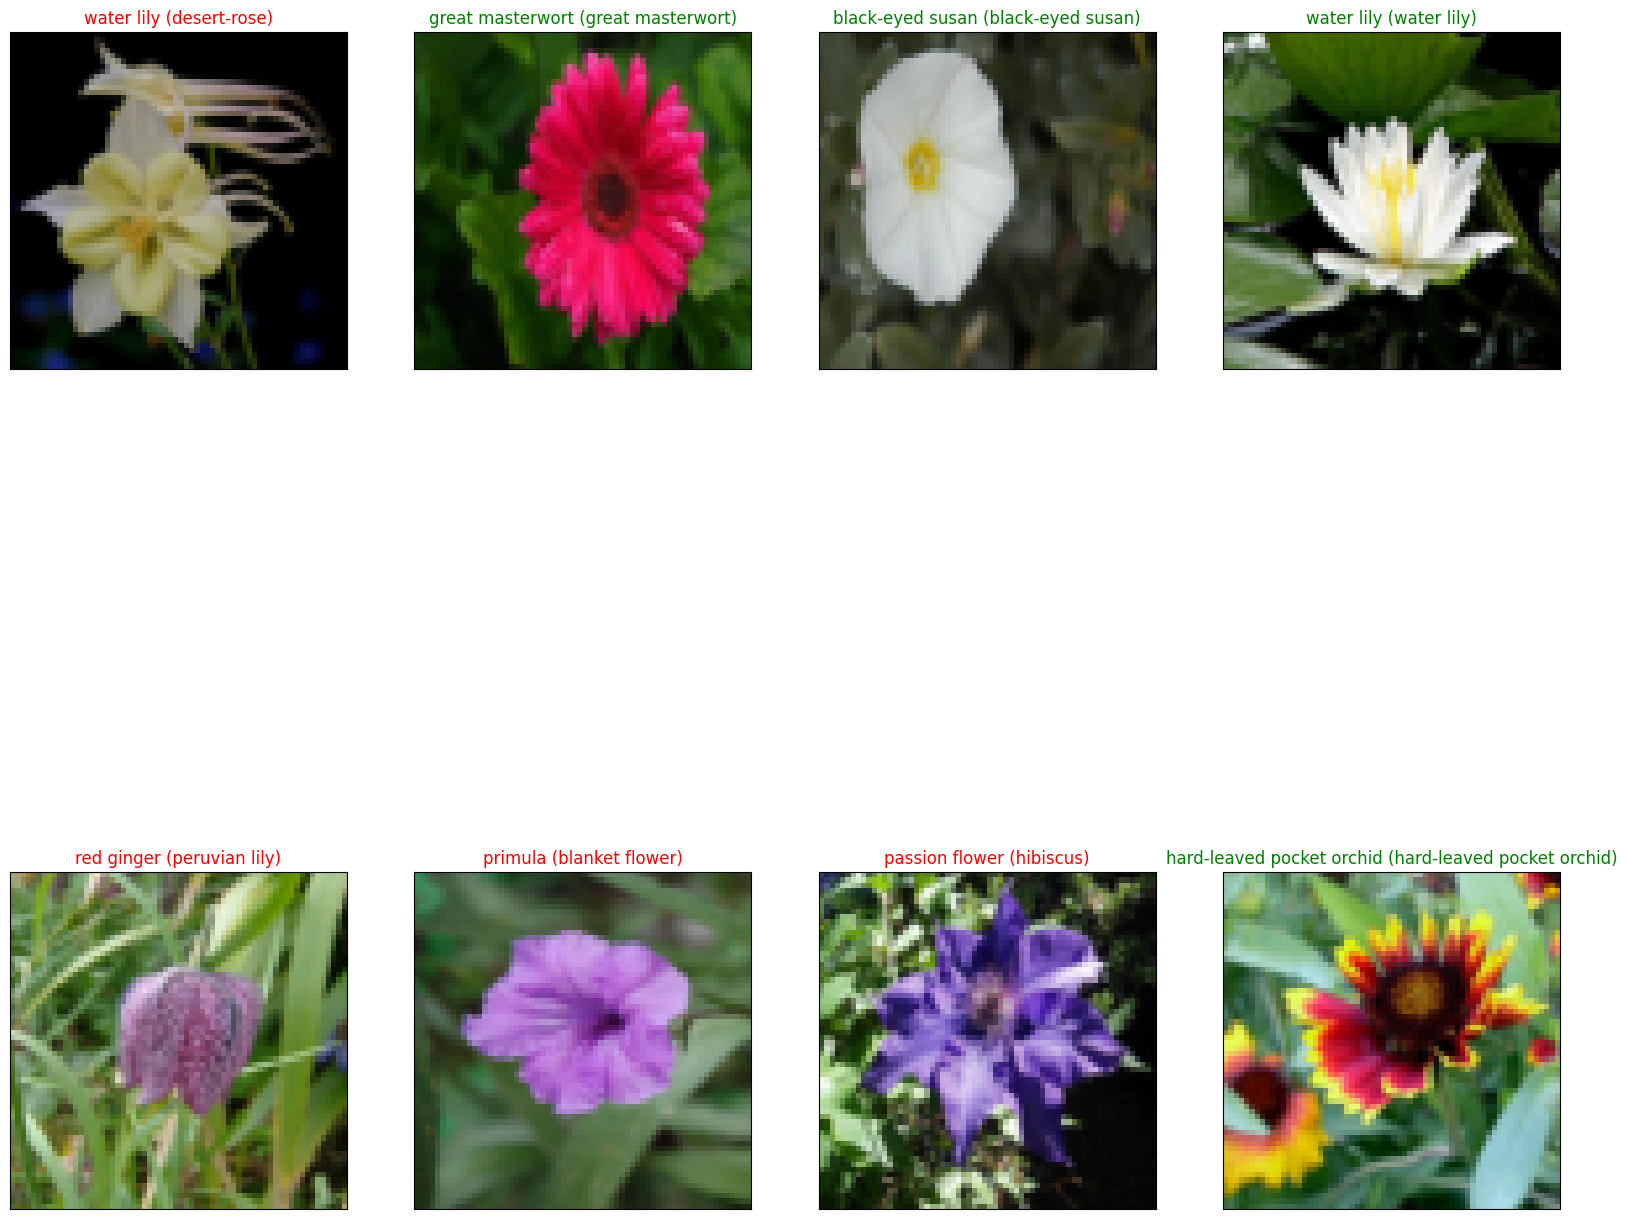

In [75]:
from matplotlib import pyplot as plt

fig=plt.figure(figsize=(20, 20))
columns =4
rows = 2

# 打印preds和labels的具体值，确认取值范围
print("\npreds前5个值：", [preds[i].item() for i in range(8)])
print("labels前5个值：", [labels[i].item() for i in range(8)])
for idx in range (columns*rows):
    ax = fig.add_subplot(rows, columns, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    ax.set_title("{} ({})".format(cat_to_name[str(preds[idx])], cat_to_name[str(labels[idx].item())]),
                 color=("green" if cat_to_name[str(preds[idx])]==cat_to_name[str(labels[idx].item())] else "red"))
plt.show()